# Walmart Sales Forecast

**Goal:** Predict future weekly sales using historical Walmart data. This notebook demonstrates time-based feature engineering (date parts, lag features), simple regression models, evaluation, and visualizing actual vs predicted sales.

**Dataset:** https://www.kaggle.com/datasets/iamprateek/wallmart-sales-forecast-datasets

## Setup


In [3]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

print('Libraries loaded')

Libraries loaded


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# Adjust this path to where you placed the dataset CSVs
path = '/content/drive/MyDrive/Colab Notebooks/data/wallmart_sales'


train_csv = os.path.join(path, 'train.csv')

if not os.path.exists(train_csv):
    print(f"Warning: {train_csv} not found. Please download the dataset and place it in {path}.")
else:
    print('Found dataset:', train_csv)

Found dataset: /content/drive/MyDrive/Colab Notebooks/data/wallmart_sales/train.csv


## Load data (example)

This cell reads `train.csv` and parses dates. Update column names if your dataset differs.

In [9]:
if os.path.exists(train_csv):
    df = pd.read_csv(train_csv, parse_dates=['Date'])
    print('Data shape:', df.shape)
    display(df.head())
else:
    # Create a small synthetic example so the rest of the notebook can run for demo
    rng = pd.date_range('2018-01-01', periods=200, freq='W')
    df = pd.DataFrame({
        'Store': 1,
        'Dept': 1,
        'Date': rng,
        'Weekly_Sales': (1000 + (np.sin(np.arange(len(rng))/10)*200) + np.random.normal(0,80,len(rng))).round(2)
    })
    print('Using synthetic demo data')
    display(df.head())

Data shape: (421570, 5)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


## Preprocessing & Feature Engineering

We'll create date features (year, month, week, dayofweek) and lag features (previous 1,2,3 weeks).

In [11]:
# --- Preprocessing & Feature Engineering (fixed rolling mean) ---
df = df.sort_values(['Store','Dept','Date']).reset_index(drop=True)

# Basic date features
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['week'] = df['Date'].dt.isocalendar().week.astype(int)
df['dayofweek'] = df['Date'].dt.dayofweek

# Lag features (for single store/dept example). For multi-store/dept you'd group and shift.
lag_weeks = [1,2,3]
for lag in lag_weeks:
    df[f'lag_{lag}'] = df.groupby(['Store','Dept'])['Weekly_Sales'].shift(lag)

# Rolling mean features (shift first so current week not included)
# Use transform so result aligns with df index
df['rolling_mean_4'] = df.groupby(['Store','Dept'])['Weekly_Sales'] \
                        .transform(lambda x: x.shift(1).rolling(window=4, min_periods=1).mean())

# Drop rows with NA in lag features (first few rows per group)
df_model = df.dropna(subset=[f'lag_{l}' for l in lag_weeks]).copy()
print('Prepared data shape for modeling:', df_model.shape)
df_model.head()


Prepared data shape for modeling: (411681, 13)


,Store,Dept,Date,Weekly_Sales,IsHoliday,year,month,week,dayofweek,lag_1,lag_2,lag_3,rolling_mean_4
3,1,1,2010-02-26,19403.54,False,2010,2,8,4,41595.55,46039.49,24924.50,37519.846667
4,1,1,2010-03-05,21827.90,False,2010,3,9,4,19403.54,41595.55,46039.49,32990.770000
5,1,1,2010-03-12,21043.39,False,2010,3,10,4,21827.90,19403.54,41595.55,32216.620000
6,1,1,2010-03-19,22136.64,False,2010,3,11,4,21043.39,21827.90,19403.54,25967.595000
7,1,1,2010-03-26,26229.21,False,2010,3,12,4,22136.64,21043.39,21827.90,21102.867500


## Train / Test split (time-based)

We'll use the last 20% of time as test data to mimic forecasting future periods.

In [12]:
# Define features and target
features = ['year','month','week','dayofweek'] + [f'lag_{l}' for l in lag_weeks] + ['rolling_mean_4']
target = 'Weekly_Sales'

# Sort by date and split
df_model = df_model.sort_values('Date')
split_idx = int(len(df_model) * 0.8)
train_df = df_model.iloc[:split_idx]
test_df = df_model.iloc[split_idx:]

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

print('Train size:', X_train.shape, 'Test size:', X_test.shape)

Train size: (329344, 8) Test size: (82337, 8)


## Model 1 — Linear Regression

In [14]:
from sklearn.metrics import mean_squared_error
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

# Older scikit-learn: compute RMSE manually
mse_lr = mean_squared_error(y_test, pred_lr)
rmse_lr = np.sqrt(mse_lr)

print('LinearRegression RMSE:', rmse_lr)


LinearRegression RMSE: 3257.5067089634026


## Model 2 — Random Forest

In [16]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))

print('RandomForest RMSE:$', rmse_rf)

RandomForest RMSE: 3083.8389787676742


## Plot Actual vs Predicted

Plot predictions for the test period. If you have multiple stores/depts you may want to aggregate or select one series for visualization.

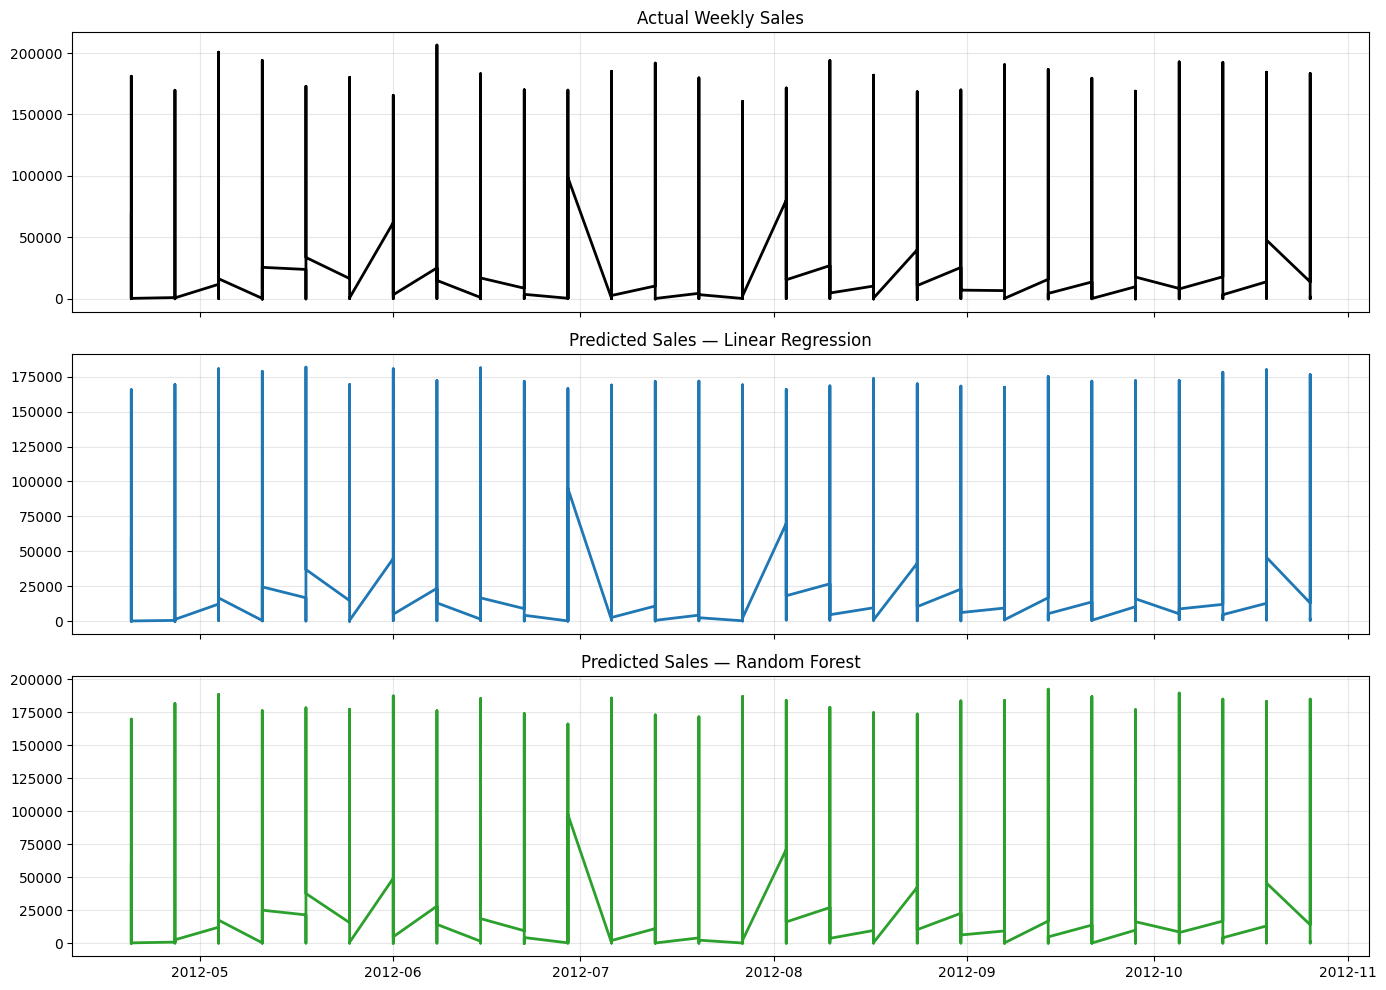

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(14,10), sharex=True)

# Actual Sales
axes[0].plot(test_df['Date'], y_test, color='black', linewidth=2)
axes[0].set_title("Actual Weekly Sales")
axes[0].grid(alpha=0.3)

# Linear Regression Predictions
axes[1].plot(test_df['Date'], pred_lr, color='tab:blue', linewidth=2)
axes[1].set_title("Predicted Sales — Linear Regression")
axes[1].grid(alpha=0.3)

# Random Forest Predictions
axes[2].plot(test_df['Date'], pred_rf, color='tab:green', linewidth=2)
axes[2].set_title("Predicted Sales — Random Forest")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Save model

Save the best model to disk

In [21]:
import joblib
os.makedirs('models', exist_ok=True)
joblib.dump(rf, 'models/rf_walmart.pkl')
print('Saved Random Forest to models/rf_walmart.pkl')

Saved Random Forest to models/rf_walmart.pkl
